# LBM Suite2p Quickstart

``` {note}
Example dataset collected by kevin barber with Dr. Alipasha Vaziri @rockefeller university.

Animal: mk301
Date:  2025-03-01
Virus: jGCaMP8s
Framerate: 17hz
FOV: 900um x 900um
Resolution: 2um x 2um x 16um
```

In [2]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import mbo_utilities as mbo
import fastplotlib as fpl

import lbm_suite2p_python as lsp

In [3]:
animal_path = Path(r"D:\W2_DATA\kbarber\2025_03_01\mk301")
raw_path = animal_path.joinpath("green")
assembled_path = animal_path.joinpath("assembled")
save_path = animal_path.joinpath("results")  # where the z-plane tiff files live
print(f"Saving raw tiffs to:        {assembled_path}")
print(f"Saving suite2p results to:  {save_path}")

Saving raw tiffs to:        D:\W2_DATA\kbarber\2025_03_01\mk301/assembled
Saving suite2p results to:  D:\W2_DATA\kbarber\2025_03_01\mk301/results


## Assembly

In [5]:
files = list(raw_path.glob("*tif*"))
scan = mbo.read_scan(files, join_contiguous=True)

FileNotFoundError: Pathname(s) [] do not match any files in disk.

RFBOutputContext()

JupyterRenderCanvas(css_height='500.0px', css_width='480.0px')
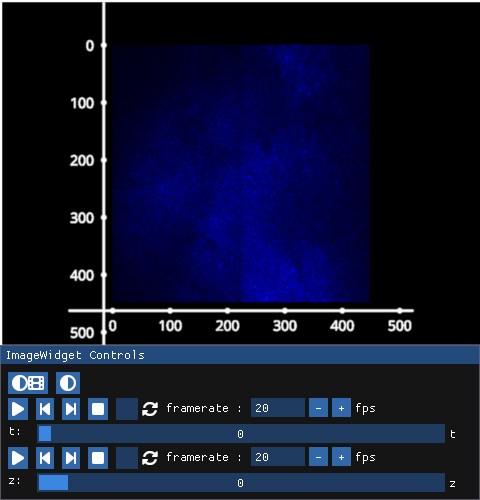

In [4]:
figure_kwargs={"size": (480, 500)}

iw = fpl.ImageWidget(
    data=scan,
    figure_kwargs=figure_kwargs,
    cmap="gnuplot2",
    graphic_kwargs={"vmin": -300, "vmax": 12000},
    histogram_widget=False
)

# free up some space
for subplot in iw.figure:
    subplot.docks["right"].size = 0
    subplot.toolbar = False

iw.show()

Saving raw tiffs to:        D:\W2_DATA\kbarber\2025_03_01\mk301\assembled
Saving suite2p results to:  D:\W2_DATA\kbarber\2025_03_01\mk301\results


## Save assembled files

In [ ]:
mbo.save_as(scan, assembled_path, append_str='_demo',overwrite=True, planes=[1], trim_edge=[4, 4, 6, 8])

In [20]:
input_files = mbo.get_files(assembled_path, str_contains='tif', max_depth=3)
raw_files = mbo.get_files(raw_path, str_contains='tif', max_depth=3)
metadata = mbo.get_metadata(raw_files[0], verbose=True)
# ops = suite2p.default_ops()
# ops = mbo.params_from_metadata(metadata, ops)

Reading tiff series data...
Reading tiff pages...
Raw tiff fully read.
Saving all metadata to metadata["all"]


In [21]:
metadata["all"]

{'version': 4,
 'FrameData': {'SI.LINE_FORMAT_VERSION': 1,
  'SI.PREMIUM': True,
  'SI.TIFF_FORMAT_VERSION': 4,
  'SI.VERSION_COMMIT': 'b0e89ff7717e60826b56173afe65ddb1ea6efb87',
  'SI.VERSION_MAJOR': 2023,
  'SI.VERSION_MINOR': 1,
  'SI.VERSION_UPDATE': 0,
  'SI.acqState': 'loop',
  'SI.acqsPerLoop': 600,
  'SI.errorMsg': '',
  'SI.extTrigEnable': 1,
  'SI.fieldCurvatureRxs': [],
  'SI.fieldCurvatureRys': [],
  'SI.fieldCurvatureTilt': 0,
  'SI.fieldCurvatureTip': 0,
  'SI.fieldCurvatureZs': [],
  'SI.hBeams.enablePowerBox': False,
  'SI.hBeams.errorMsg': '',
  'SI.hBeams.flybackBlanking': True,
  'SI.hBeams.interlaceDecimation': 1,
  'SI.hBeams.interlaceOffset': 0,
  'SI.hBeams.lengthConstants': inf,
  'SI.hBeams.name': 'SI Beams',
  'SI.hBeams.powerBoxEndFrame': inf,
  'SI.hBeams.powerBoxStartFrame': 1,
  'SI.hBeams.powerFractionLimits': 1,
  'SI.hBeams.powerFractions': 0.45,
  'SI.hBeams.powers': 45,
  'SI.hBeams.pzAdjust': 'scanimage.types.BeamAdjustTypes.Exponential',
  'SI.hBeam

In [32]:
import tifffile
file = raw_files[0]
tiff_file = tifffile.TiffFile(file)
meta = tiff_file.scanimage_metadata
si = meta.get('FrameData', {})

si["SI.hChannels.channelSubtractOffset"], si["SI.hScan2D.channelsSubtractOffsets"]

([True, True], [True, True])

In [33]:
si["SI.hScan2D.channelOffsets"], si["SI.hChannels.channelOffset"]

([-376, -122], [-376, -122])

In [36]:
import matplotlib.pyplot as plt

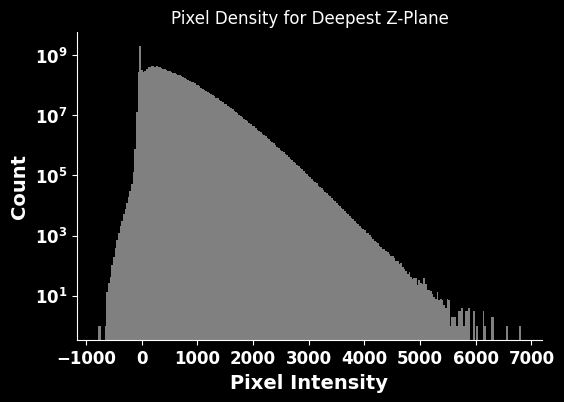

In [42]:
%matplotlib inline
import tifffile
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
zplane_1 = tifffile.memmap(input_files[0])
plt.hist(zplane_1.ravel(), bins=256, color='gray', log=True)
plt.xlabel("Pixel Intensity", fontsize=14, fontweight='bold', color='white')
plt.ylabel("Count", fontsize=14, fontweight='bold', color='white')
plt.xticks(fontsize=12, fontweight='bold', color='white')
plt.yticks(fontsize=12, fontweight='bold', color='white')
ax = plt.gca()
ax.set_facecolor('black')
plt.gcf().patch.set_facecolor('black')
plt.title("Pixel Density for Deepest Z-Plane")
plt.show()


## run sutie2p on each z-plane (same parameters)

In [39]:
save_path = save_path.parent / 'test5'
save_path.mkdir()

In [ ]:
for i in range(len(input_files)):
    if i in [9, 10, 11, 12]:
        plane_savepath = Path(save_path / f'p{i}')
        plane_savepath.mkdir(exist_ok=True)
        output_ops = lsp.run_plane(ops, input_files[i], plane_savepath)

p9
D:\W2_DATA\kbarber\2025_03_01\mk301\test5\p9
{'data_path': ['D:\\W2_DATA\\kbarber\\2025_03_01\\mk301\\assembled']}
<class 'int'>
tif
** Found 1 tifs - converting to binary **
2000 frames of binary, time 10.75 sec.
4000 frames of binary, time 11.96 sec.
6000 frames of binary, time 13.19 sec.
8000 frames of binary, time 14.45 sec.
10000 frames of binary, time 15.70 sec.
12000 frames of binary, time 16.89 sec.
14000 frames of binary, time 18.16 sec.


In [ ]:
output_ops = lsp.run_volume(ops, input_files, save_path)

In [45]:
ops_files = mbo.get_files(save_path.parent, 'ops', 8)
ops_files

['D:\\W2_DATA\\kbarber\\2025_03_01\\mk301\\p1\\plane_01_mk301\\plane0\\ops.npy',
 'D:\\W2_DATA\\kbarber\\2025_03_01\\mk301\\p2\\plane_01_mk301\\plane0\\ops.npy',
 'D:\\W2_DATA\\kbarber\\2025_03_01\\mk301\\results\\plane_01_mk301\\plane0\\ops.npy',
 'D:\\W2_DATA\\kbarber\\2025_03_01\\mk301\\test\\plane_01_mk301\\plane0\\ops.npy',
 'D:\\W2_DATA\\kbarber\\2025_03_01\\mk301\\test3\\p3\\p3\\plane0\\ops.npy',
 'D:\\W2_DATA\\kbarber\\2025_03_01\\mk301\\test3\\p4\\p4\\plane0\\ops.npy',
 'D:\\W2_DATA\\kbarber\\2025_03_01\\mk301\\test4\\p3\\p3\\plane0\\ops.npy',
 'D:\\W2_DATA\\kbarber\\2025_03_01\\mk301\\test4\\p4\\p4\\plane0\\ops.npy',
 'D:\\W2_DATA\\kbarber\\2025_03_01\\mk301\\test5\\p5\\p5\\plane0\\ops.npy',
 'D:\\W2_DATA\\kbarber\\2025_03_01\\mk301\\test5\\p6\\p6\\plane0\\ops.npy',
 'D:\\W2_DATA\\kbarber\\2025_03_01\\mk301\\test5\\p7\\p7\\plane0\\ops.npy',
 'D:\\W2_DATA\\kbarber\\2025_03_01\\mk301\\test5\\p8\\p8\\plane0\\ops.npy']

In [24]:
stat_files = mbo.get_files(save_path.parent, 'stat.npy', max_depth=5)
stat_files[:3]

['D:\\W2_DATA\\kbarber\\2025-02-10\\mk303\\results\\plane_01_demo\\plane0\\stat.npy',
 'D:\\W2_DATA\\kbarber\\2025-02-10\\mk303\\results\\plane_02_demo\\plane0\\stat.npy',
 'D:\\W2_DATA\\kbarber\\2025-02-10\\mk303\\results\\plane_03_demo\\plane0\\stat.npy']

In [ ]:
fcells_list = lsp.get_fcells_list(ops_files)
lsp.plot_fluorescence_grid_auto(fcells_list,'./fcells_list.png')

In [ ]:
output_ops = lsp.run_volume(ops, input_files, save_path=save_path, replot=True)